In [66]:
import cv2
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [38]:
DATASET_PATH = Path("data")

crack_files = list((DATASET_PATH / "Cracks").glob("*.jpg"))
non_crack_files = list((DATASET_PATH / "NonCracks").glob("*.jpg"))

print("Crack images:", len(crack_files))
print("Non-crack images:", len(non_crack_files))
print("Total:", len(crack_files) + len(non_crack_files))

Crack images: 200
Non-crack images: 200
Total: 400


(np.float64(-0.5), np.float64(447.5), np.float64(447.5), np.float64(-0.5))

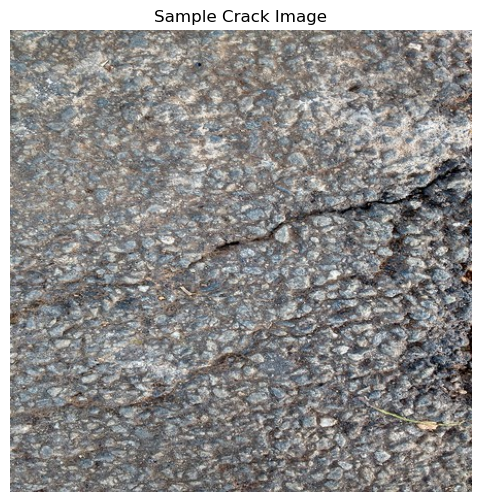

In [39]:
image = cv2.imread(str(crack_files[0]))
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.title("Sample Crack Image")
plt.axis("off")

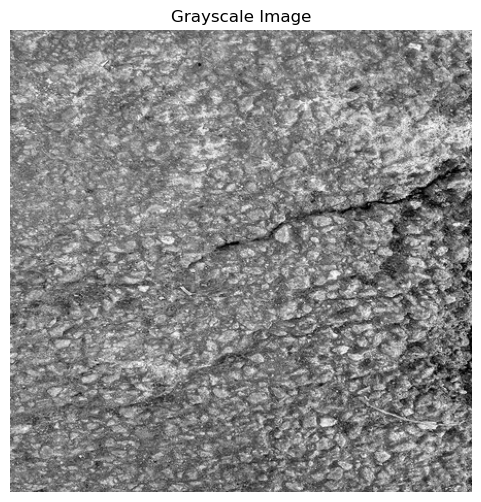

In [40]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6, 6))
plt.imshow(gray, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

In [41]:
from sklearn.model_selection import train_test_split

image_paths = crack_files + non_crack_files
labels = [1] * len(crack_files) + [0] * len(non_crack_files)

print("Total images:", len(image_paths))
print("Total labels:", len(labels))

Total images: 400
Total labels: 400


In [42]:
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

print("Training images:", len(train_paths))
print("Testing images:", len(test_paths))

Training images: 320
Testing images: 80


In [43]:
def extract_features(image_path, canny_low=100, canny_high=200):
    image = cv2.imread(str(image_path))
    image = cv2.resize(image, (128, 128))
    
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    mean_brightness = np.mean(gray)
    std_brightness = np.std(gray)
    median_brightness = np.median(gray)

    min_intensity = np.min(gray)
    max_intensity = np.max(gray)

    dark_pixel_ratio = np.mean(gray < 50)
    bright_pixel_ratio = np.mean(gray > 200)

    edges = cv2.Canny(gray, canny_low, canny_high)

    edge_count = np.sum(edges > 0)
    edge_density = edge_count / edges.size

    return [
        mean_brightness,
        std_brightness,
        median_brightness,
        min_intensity,
        max_intensity,
        dark_pixel_ratio,
        bright_pixel_ratio,
        edge_count,
        edge_density
    ]

In [44]:
X_train = np.array([
    extract_features(path)
    for path in train_paths
])

X_test = np.array([
    extract_features(path)
    for path in test_paths
])

y_train = np.array(train_labels)
y_test = np.array(test_labels)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (320, 9)
X_test shape: (80, 9)
y_train shape: (320,)
y_test shape: (80,)


In [45]:
print(X_train[:3])

[[1.18664307e+02 3.44007926e+01 1.17000000e+02 4.00000000e+00
  2.51000000e+02 1.86157227e-02 1.56250000e-02 5.29100000e+03
  3.22937012e-01]
 [1.13311401e+02 2.85697488e+01 1.13000000e+02 7.00000000e+00
  2.53000000e+02 1.53198242e-02 7.87353516e-03 4.63300000e+03
  2.82775879e-01]
 [1.55181335e+02 2.74115435e+01 1.56000000e+02 4.00000000e+01
  2.52000000e+02 2.44140625e-04 4.24194336e-02 4.81000000e+03
  2.93579102e-01]]


In [46]:
print("Feature means:")
print(X_train.mean(axis=0))

print("\nFeature standard deviations:")
print(X_train.std(axis=0))

Feature means:
[1.51060376e+02 2.75420918e+01 1.50970313e+02 4.98343750e+01
 2.49765625e+02 4.55245972e-03 6.18841171e-02 4.41766250e+03
 2.69632721e-01]

Feature standard deviations:
[1.80742946e+01 8.37449050e+00 1.81014043e+01 3.25001068e+01
 5.37163321e+00 1.30021679e-02 5.66865534e-02 1.69830016e+03
 1.03656016e-01]


In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [48]:
X_train_scaled.mean(axis=0)

array([-3.21964677e-16,  2.63573885e-15, -3.20576898e-16, -3.74700271e-17,
        7.77156117e-17,  6.59194921e-18,  4.23272528e-17, -1.97064587e-16,
       -1.97064587e-16])

In [49]:
X_train_scaled.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [50]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

start = time.perf_counter()

model.fit(X_train_scaled, y_train)

training_time = time.perf_counter() - start

In [51]:
start = time.perf_counter()

y_pred = model.predict(X_test_scaled)

prediction_time = time.perf_counter() - start

In [52]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
print("Training time :", training_time)
print("Prediction time:", prediction_time)

Accuracy : 0.8875
Precision: 0.8974358974358975
Recall   : 0.875
F1-score : 0.8860759493670886
Training time : 0.012068258998624515
Prediction time: 0.0002943459985544905


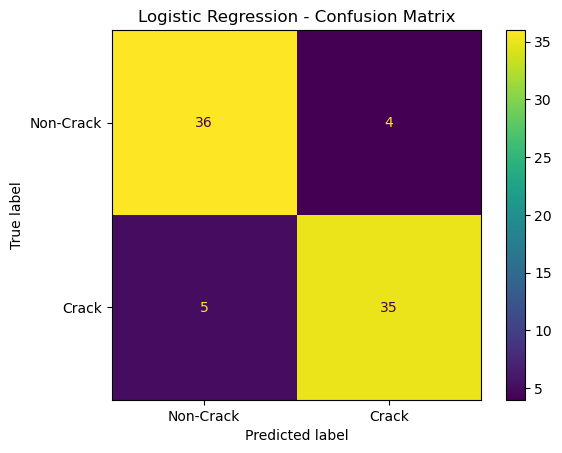

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Crack", "Crack"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [54]:
baseline_result = {
    "Approach": "Baseline",
    "Model": "Logistic Regression",
    "Features": 9,
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "Training Time (s)": training_time,
    "Prediction Time (s)": prediction_time
}

baseline_df = pd.DataFrame([baseline_result])
baseline_df

,Approach,Model,Features,Accuracy,Precision,Recall,F1,Training Time (s),Prediction Time (s)
0,Baseline,Logistic Regression,9,0.8875,0.897436,0.875,0.886076,0.012068,0.000294


In [60]:
def extract_threshold_features(image_path, canny_low=50, canny_high=150):
    image = cv2.imread(str(image_path))
    image = cv2.resize(image, (128, 128))

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    mean_brightness = np.mean(gray)
    std_brightness = np.std(gray)
    median_brightness = np.median(gray)
    min_intensity = np.min(gray)
    max_intensity = np.max(gray)

    dark_pixel_ratio = np.mean(gray < 50)
    bright_pixel_ratio = np.mean(gray > 200)

    edges = cv2.Canny(gray, canny_low, canny_high)

    edge_count = np.sum(edges > 0)
    edge_density = edge_count / edges.size

    return [
        mean_brightness,
        std_brightness,
        median_brightness,
        min_intensity,
        max_intensity,
        dark_pixel_ratio,
        bright_pixel_ratio,
        edge_count,
        edge_density
    ]

In [61]:
X_train_threshold = np.array([
    extract_threshold_features(path)
    for path in train_paths
])

X_test_threshold = np.array([
    extract_threshold_features(path)
    for path in test_paths
])

print("X_train_threshold shape:", X_train_threshold.shape)
print("X_test_threshold shape:", X_test_threshold.shape)

X_train_threshold shape: (320, 9)
X_test_threshold shape: (80, 9)


In [62]:
scaler_threshold = StandardScaler()

X_train_threshold_scaled = scaler_threshold.fit_transform(
    X_train_threshold
)

X_test_threshold_scaled = scaler_threshold.transform(
    X_test_threshold
)

In [63]:
model_threshold = LogisticRegression(max_iter=1000)

start = time.perf_counter()

model_threshold.fit(
    X_train_threshold_scaled,
    y_train
)

training_time_threshold = time.perf_counter() - start

start = time.perf_counter()

y_pred_threshold = model_threshold.predict(
    X_test_threshold_scaled
)

prediction_time_threshold = time.perf_counter() - start

In [64]:
accuracy_threshold = accuracy_score(y_test, y_pred_threshold)
precision_threshold = precision_score(y_test, y_pred_threshold)
recall_threshold = recall_score(y_test, y_pred_threshold)
f1_threshold = f1_score(y_test, y_pred_threshold)

print("Threshold-Tuned Representation")
print("--------------------------------")
print("Accuracy :", accuracy_threshold)
print("Precision:", precision_threshold)
print("Recall   :", recall_threshold)
print("F1 Score :", f1_threshold)
print("Training time   :", training_time_threshold)
print("Prediction time :", prediction_time_threshold)
print("Number of features:", X_train_threshold.shape[1])

Threshold-Tuned Representation
--------------------------------
Accuracy : 0.9
Precision: 0.9
Recall   : 0.9
F1 Score : 0.9
Training time   : 0.008384708999074064
Prediction time : 0.0003560799996193964
Number of features: 9


Confusion Matrix:
[[36  4]
 [ 4 36]]


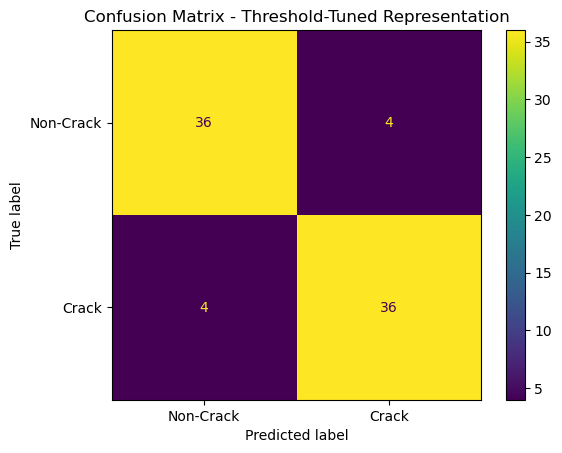

In [65]:
cm_threshold = confusion_matrix(y_test, y_pred_threshold)

print("Confusion Matrix:")
print(cm_threshold)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_threshold,
    display_labels=["Non-Crack", "Crack"]
)

disp.plot()
plt.title("Confusion Matrix - Threshold-Tuned Representation")
plt.show()